R²: 0.932
RMSE: 429.21


,Feature,Coefficient (per 1 std increase)
0,PCEPILFE_PC1,156.204220
1,GPDIC1,2162.078741
2,GCEC1,2338.539862
3,NETEXC,367.062441


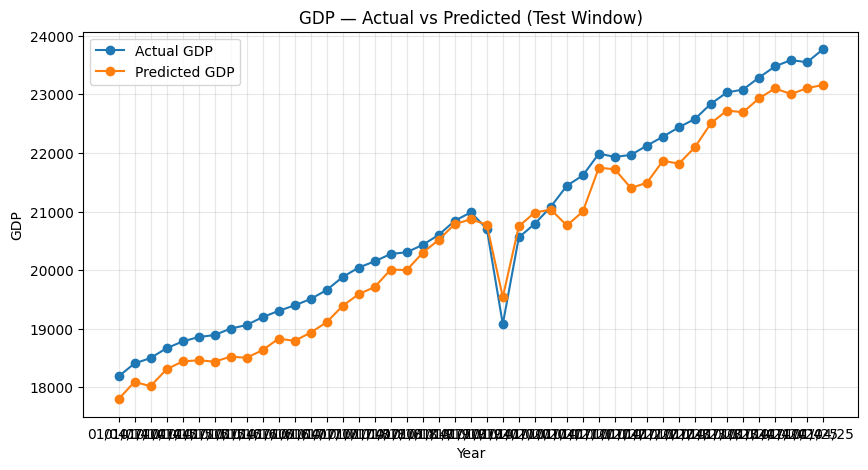

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


# ---- Read the CSV already in your Colab environment ----
df = pd.read_csv("US GDP Factors(Sheet1).csv")  # CHANGE FILE NAME ACCORDINGLY

# ---- Define target and features ----
TARGET_COL = "GDPC1"
#consumption,investmet, gov , net
FEATURE_COLS = ["PCEPILFE_PC1", "GPDIC1", "GCEC1", "NETEXC"]

# ---- Clean and sort ----
# for col in [TARGET_COL] + FEATURE_COLS + ["observation_date"]:
#     df[col] = pd.to_numeric(df[col], errors="coerce")
# df = df.dropna(subset=[TARGET_COL] + FEATURE_COLS + ["observation_date"]).sort_values("observation_date").reset_index(drop=True)

# ---- Split (time-aware 80/20) ----
split_idx = int(len(df) * 0.8)
X = df[FEATURE_COLS].values
y = df[TARGET_COL].values
years = df["observation_date"].values

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
years_test = years[split_idx:]

# ---- Normalize features ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- Train and evaluate ----
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:,.2f}")

# ---- Coefficients ----
coef_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Coefficient (per 1 std increase)": model.coef_
})
display(coef_df)

# ---- Plot ----
plt.figure(figsize=(10,5))
plt.plot(years_test, y_test, marker="o", label="Actual GDP")
plt.plot(years_test, y_pred, marker="o", label="Predicted GDP")
plt.title("GDP — Actual vs Predicted (Test Window)")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
